In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
%load_ext autoreload
%autoreload 2

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# Load data

In [3]:
train_data = pd.read_csv('../data/raw/train.csv', index_col='id')
test_data = pd.read_csv('../data/raw/test.csv', index_col='id')
original_data = pd.read_csv('../data/raw/loan_dataset_20000.csv')

# Initial data exploration

In [8]:
train_data.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
id,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
test_data.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
id,,,,,,,,,,,
593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [9]:
original_data.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


## Training set and test set:
- numerical columns: annual_income, debt_to_income_ratio, loan_amount, interest_rate, credit_score
- categorical columns: gender, marital_status, education_level, employment_status, loan_purpose, grade_subgrade
- target: loan_paid_back
## Original data set:
- numerical columns: columns from training set with additional features: monthly_income, loan_term, installment, total_credit_limit, current_balance
- categorical columns: columns from training set with additional features: age, loan_term, num_of_open_accounts, delinquency_history, num_of_delinquencies

We treat some of the numerical features with limited sets of integer values e.g. num_of_open_accounts as categorical.

In [24]:
def basic_summary(data: pd.DataFrame, name: str, categorical_columns: list):

    print(f"==========={name} summary===========")
    print(f"Number of missing values:\n{data.isnull().sum()}\n")
    print(f"Data types:\n{data.dtypes}\n")
    print(data.describe())
    for col in categorical_columns:
        print(data[col].value_counts())

In [46]:
categorical_features_train_test = ['marital_status', 'education_level', 'gender', 'employment_status', 'loan_purpose', 'grade_subgrade']
numerical_features_train_test = ['annual_income', 'debt_to_income_ratio', 'loan_amount', 'interest_rate', 'credit_score']

target = 'loan_paid_back'

numerical_features_original_only = ['age','monthly_income', 'installment', 'total_credit_limit', 'current_balance']
categorical_features_original_only = ['loan_term', 'num_of_open_accounts', 'delinquency_history', 'num_of_delinquencies']

categorical_features_original = categorical_features_train_test + categorical_features_original_only
numerical_features_original = numerical_features_train_test + numerical_features_original_only

basic_summary(train_data,"train", categorical_features_train_test)
basic_summary(test_data, "test", categorical_features_train_test)
basic_summary(original_data, "original", numerical_features_train_test)

===========train summary===========
Number of missing values:
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
id_bucket               0
dtype: int64

Data types: 
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                  float64
marital_status          float64
education_level         float64
employment_status       float64
loan_purpose            float64
grade_subgrade          float64
loan_paid_back          float64
id_bucket                 int64
dtype: object

       annual_income  debt_to_income_ratio   credit_score    loan_amount  \
count  593994.000000         593994.000000  593994.000000  593994.

# Univariate analysis

## Target class distribution:

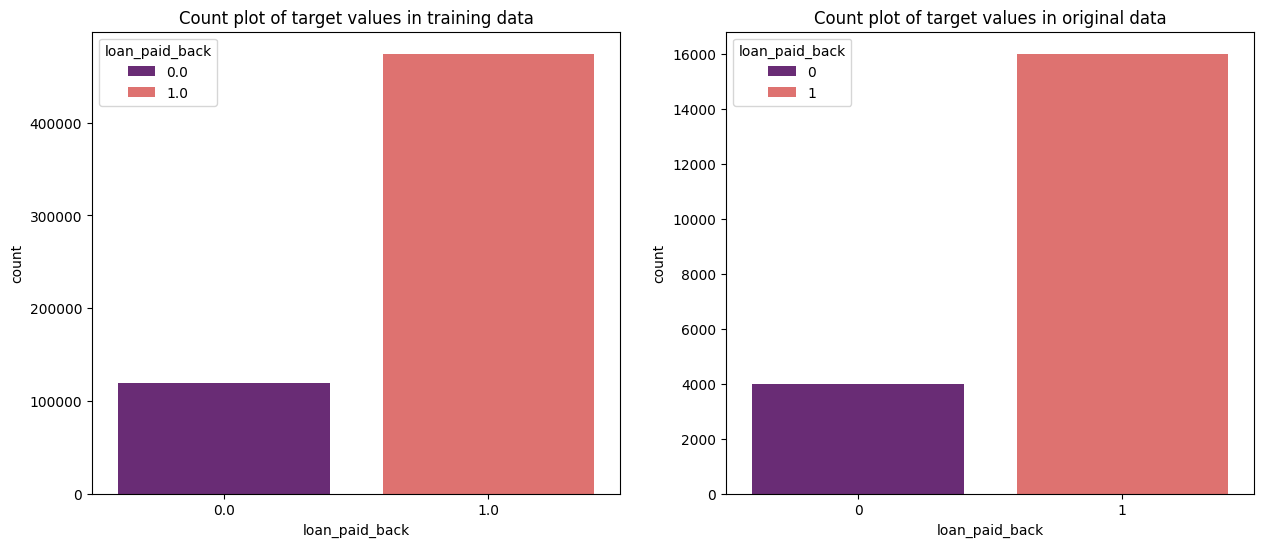

Percent of loans paid back in training data is 79.88%
Percent of loans paid back in original data is 79.99%


In [22]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
sns.countplot(x = 'loan_paid_back', data = train_data, hue = 'loan_paid_back', palette='magma')
plt.title('Count plot of target values in training data')
plt.grid(False)
plt.subplot(1,2,2)
sns.countplot(x = 'loan_paid_back', data = original_data, hue = 'loan_paid_back', palette='magma')
plt.title('Count plot of target values in original data')
plt.grid(False)
plt.show()
target_paid_percentage = train_data[target].sum() / train_data[target].count()
print(f'Percent of loans paid back in training data is {target_paid_percentage * 100:.2f}%')
target_paid_percentage = original_data[target].sum() / original_data[target].count()
print(f'Percent of loans paid back in original data is {target_paid_percentage * 100:.2f}%')

We can see a clear disproportion in target classes, but the distribution is the same for both training and original data sets. It's a good argument for using a stratified kfold approach in cross-validation of a classifier model.

# Class distributions for each categorical feature and comparison between all data sets

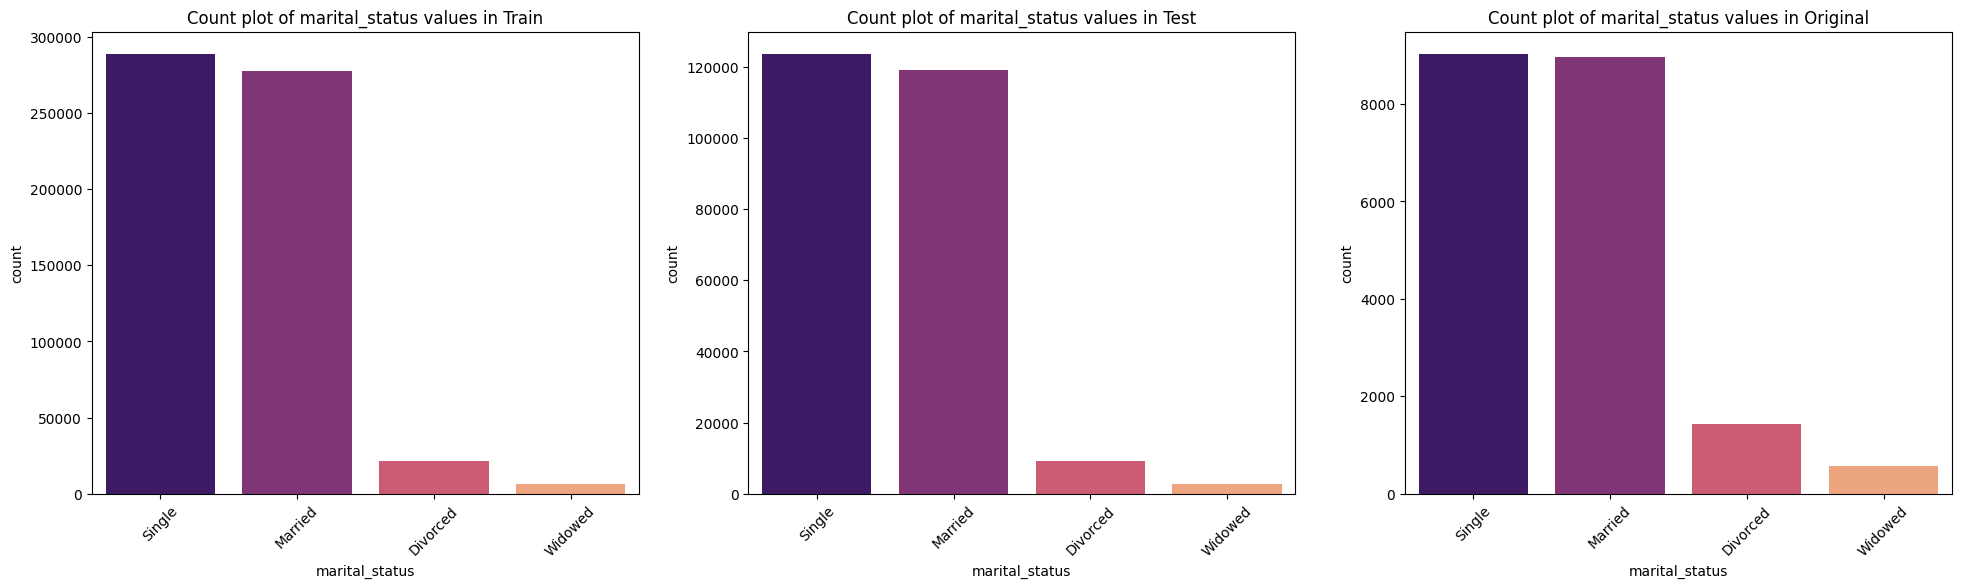

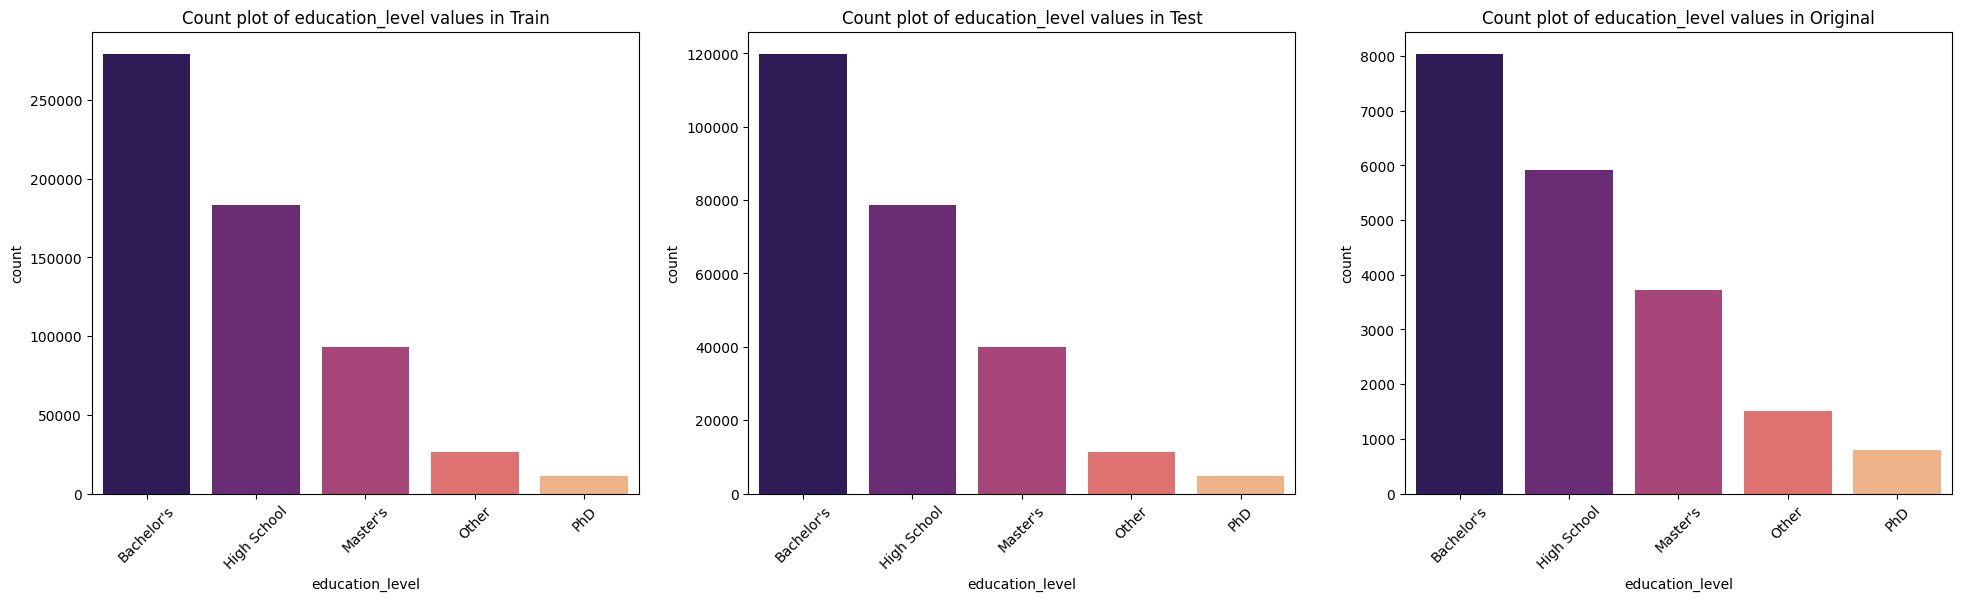

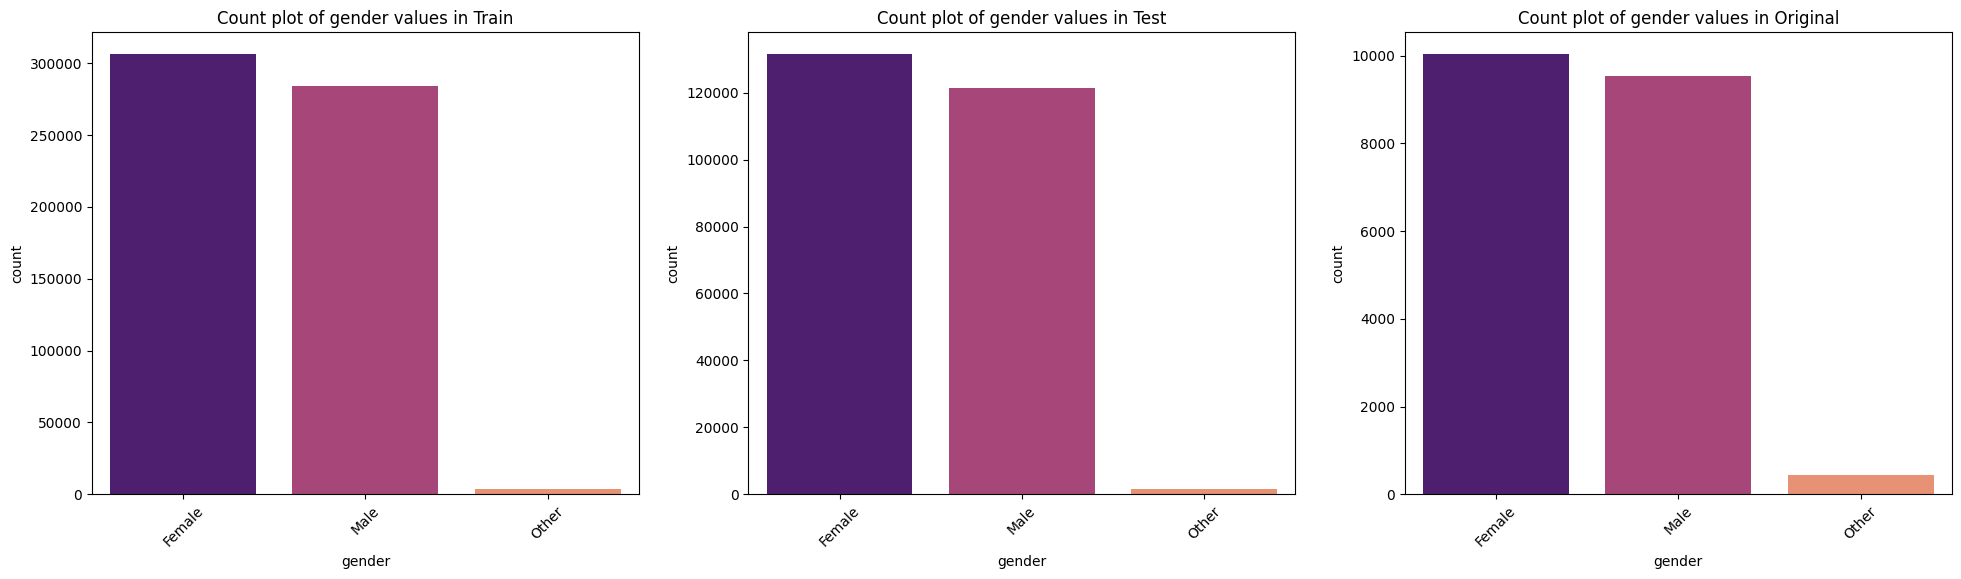

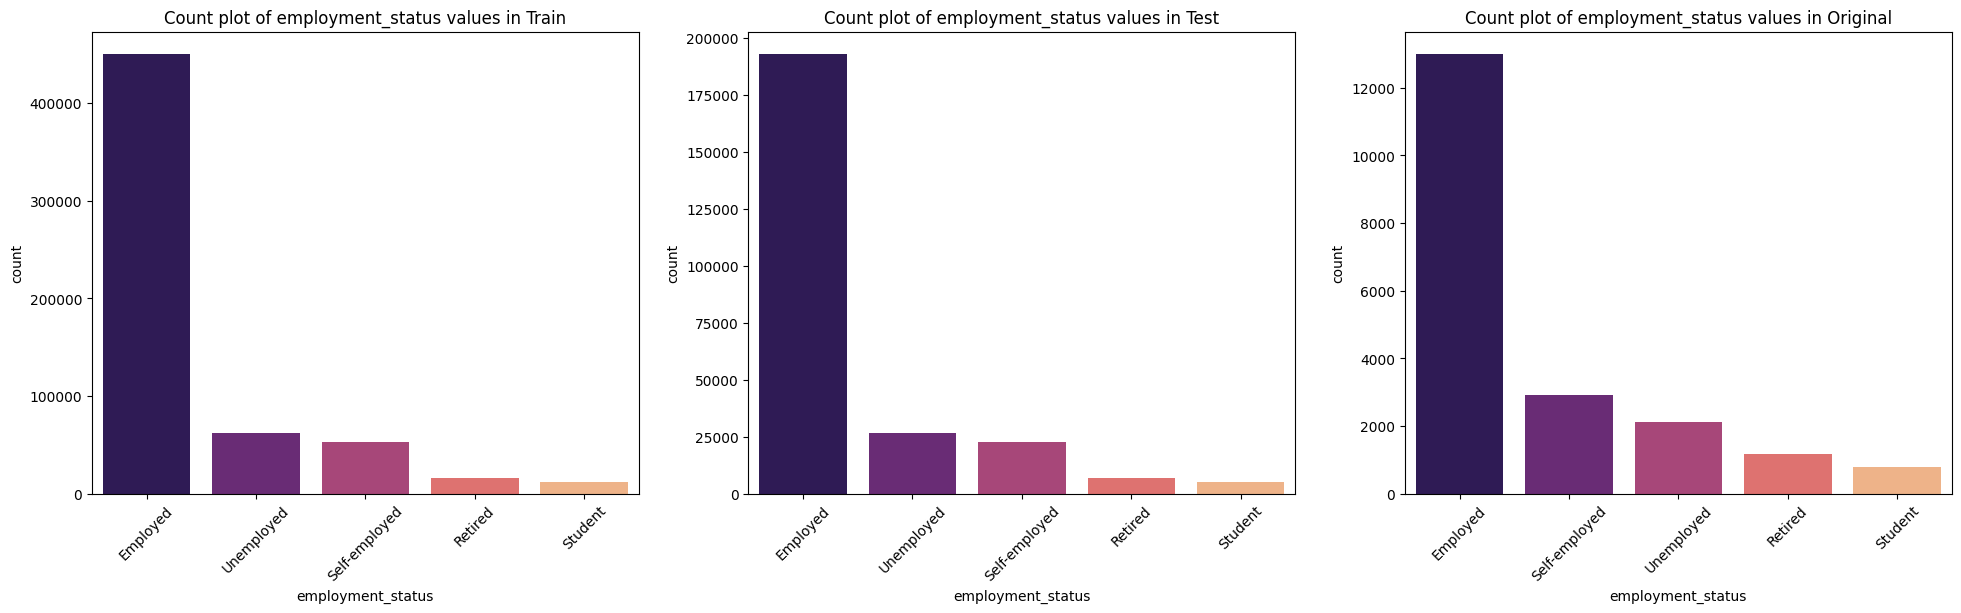

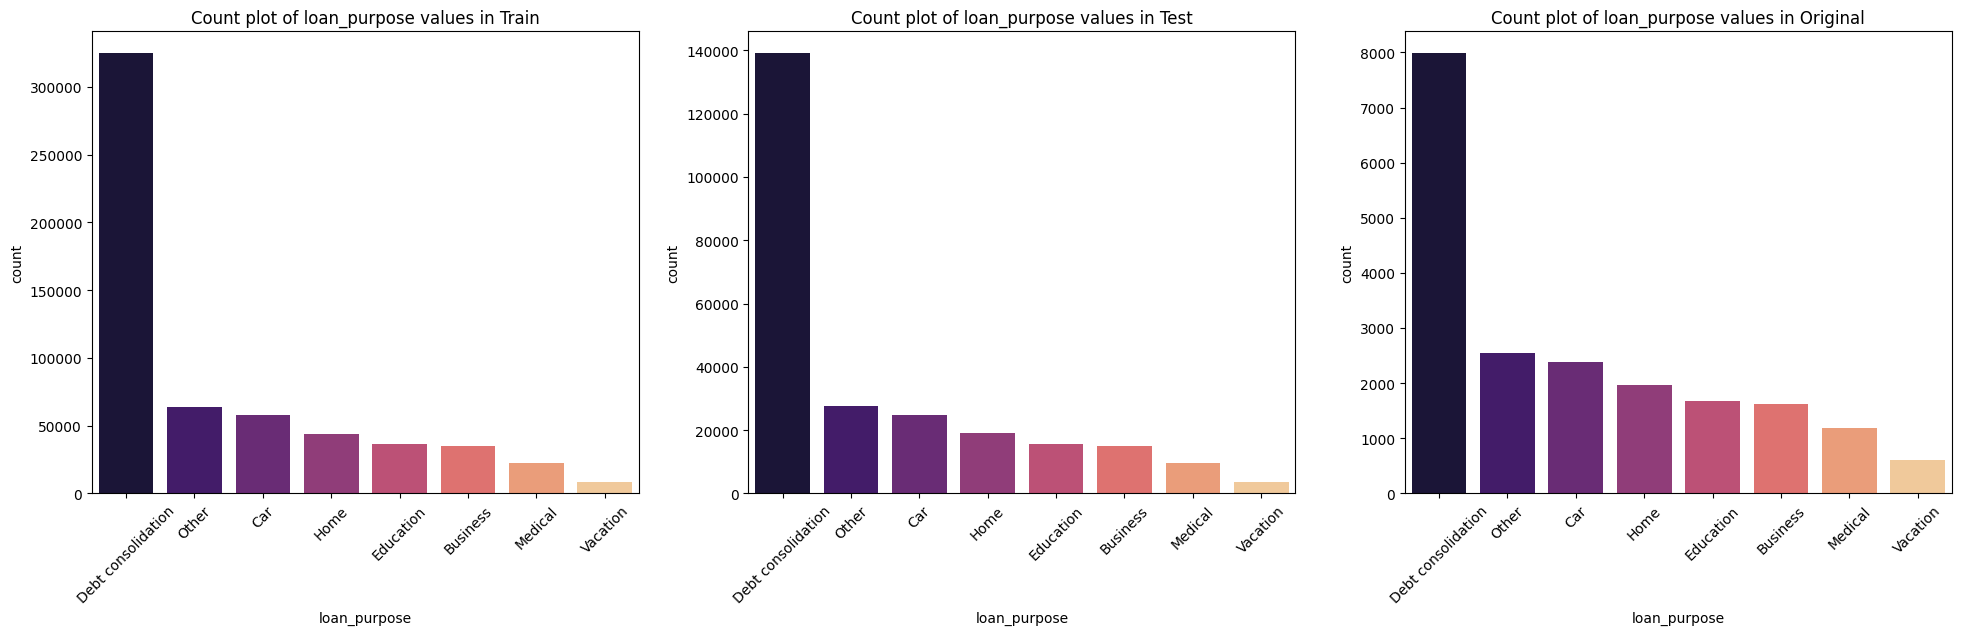

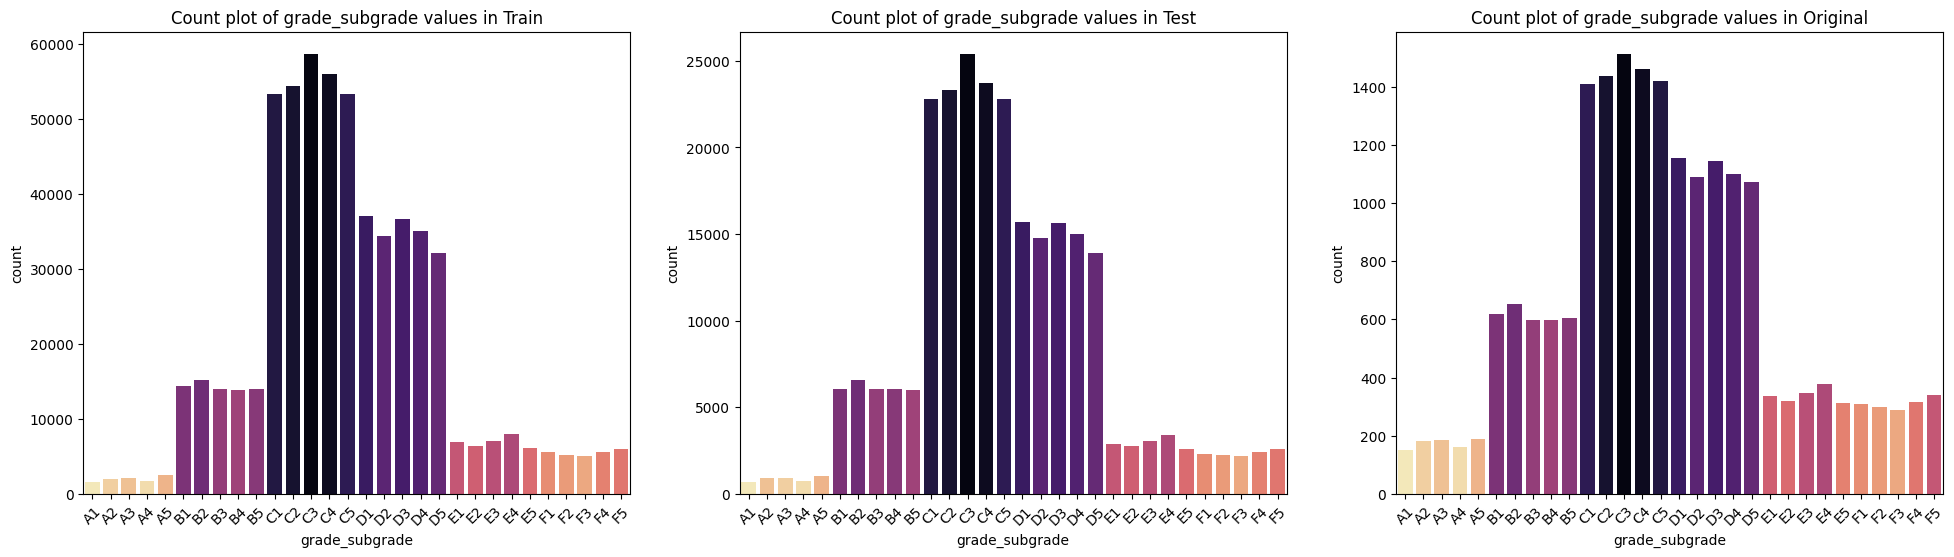

In [40]:
data_sets = [train_data, test_data, original_data]
data_set_names = ["Train", "Test", "Original"]
cat_cols = categorical_features_train_test.copy()
cat_cols.remove('credit_score')
for feature in cat_cols:
    plt.figure(figsize=(24, 6))
    for i in range(1,4):
        if feature == 'grade_subgrade':
            order = sorted(train_data[feature].unique())
        else:
            order = data_sets[i - 1][feature].value_counts().index
        plt.subplot(1, 3, i)
        sns.countplot(x = feature, data = data_sets[i - 1], hue = feature,hue_order=data_sets[i - 1][feature].value_counts().index, palette='magma', order=order)
        plt.title(f'Count plot of {feature} values in {data_set_names[i - 1]}')
        plt.xticks(rotation=45)
    plt.show()

# Analysis of produced plots:
- ## Marital status:
    We can see that the distributions are similar in all data sets. 'Single' and 'Married' classes are clearly dominant and are similar in counts, therefore, it's likely that this feature won't be a good predictor for the target class.
- ## Education level:
    In this feature there is more variance than in the marital status of the borrower. However, we can see that borrowers with a bachelor's degree and high school education are the most numerous among this feature, which can be explained by student loans. We can explore that further during bivariate analysis.
- ## Gender:
    There is little variance in this feature, with an underrepresented class 'other'. It's most likely that this feature won't be a good predictor for the target class.
- ## Employment status:
    We can see one dominating class 'Employed', which intuitively makes sense, since people usually borrow money with the intent to pay it back, which requires a stable income.
- ## Loan purpose:
    Once again, there is one clearly dominating class 'Debt consolidation'. Right now it's hard to say whether this feature contains much signal. We will investigate this further in bivariate analysis.
- ## Grade subgrade:
    This is a perfect example of an ordinal categorical feature, since we have an inherent ordering within classes. While there is significant variance between grades, it's much less visible in subgrades of a given grade. We can make an assumption that whole grades are better predictors than subgrades. The distribution resembles a normal distribution.


# Value distributions for each numerical feature and comparison between all data sets

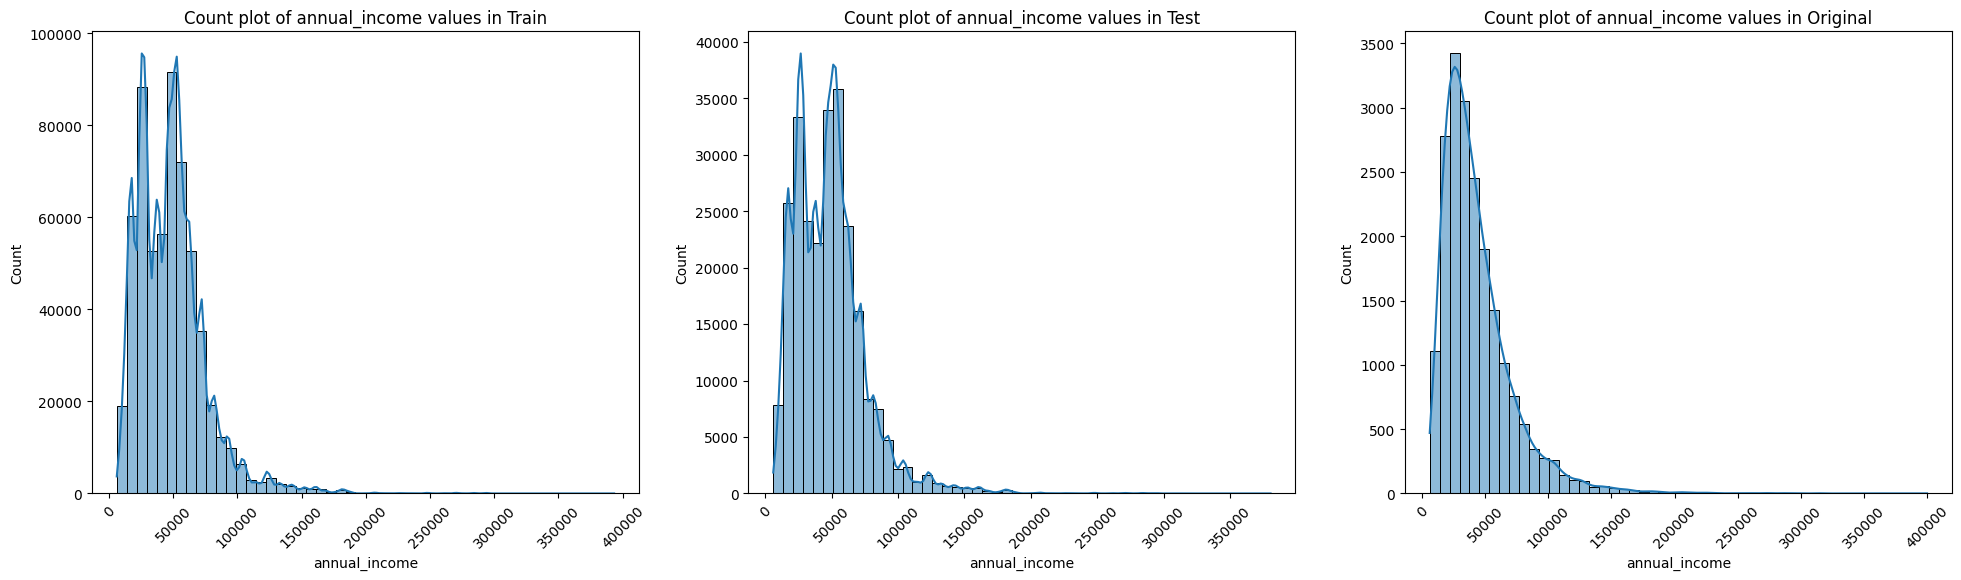

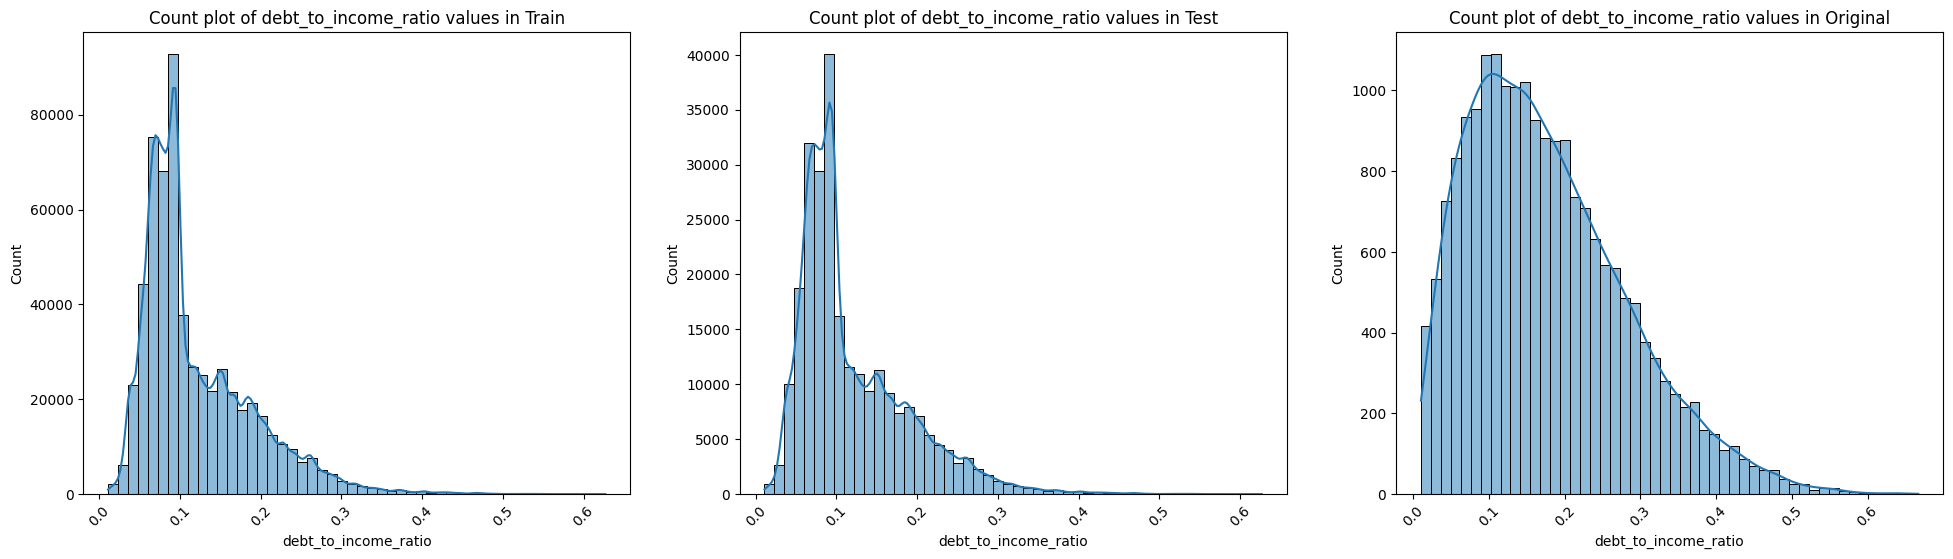

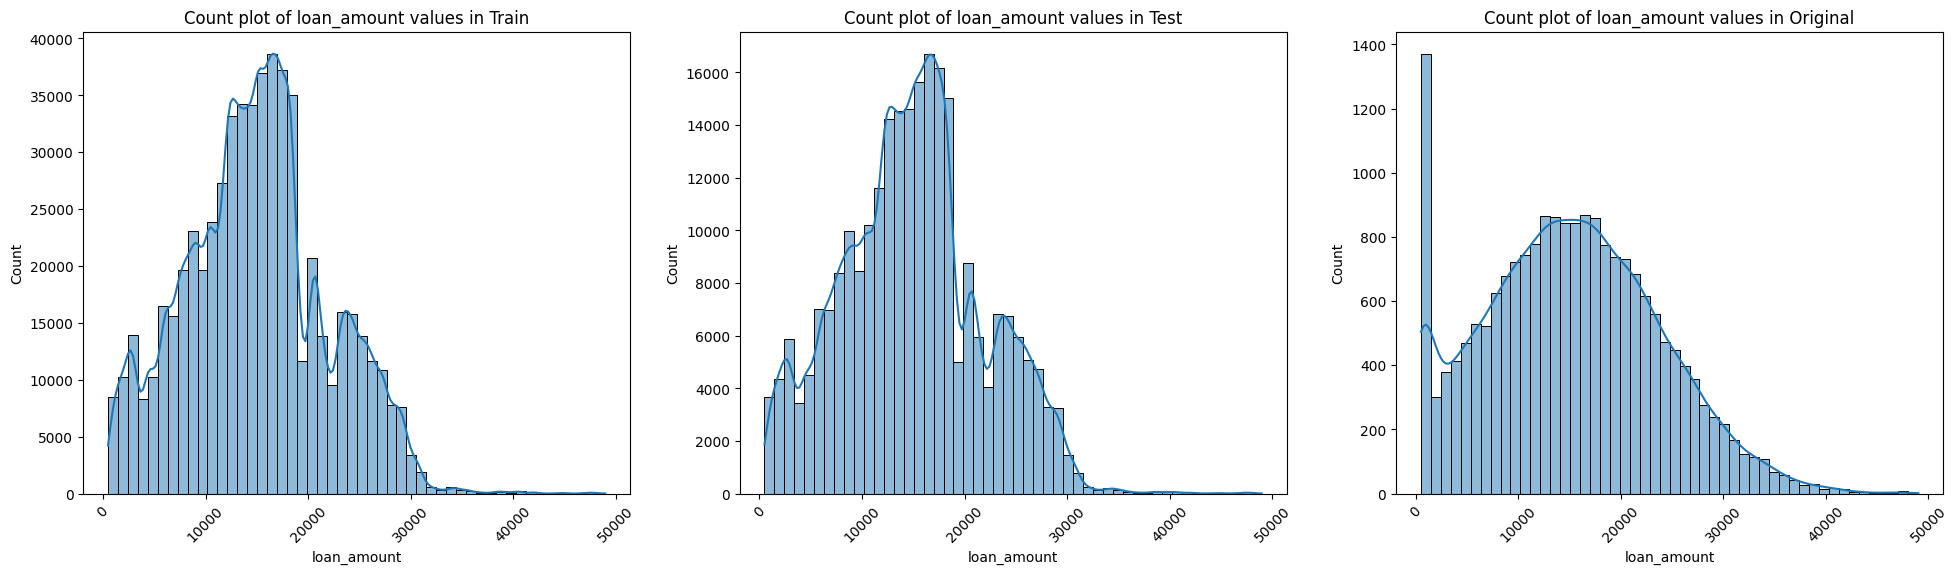

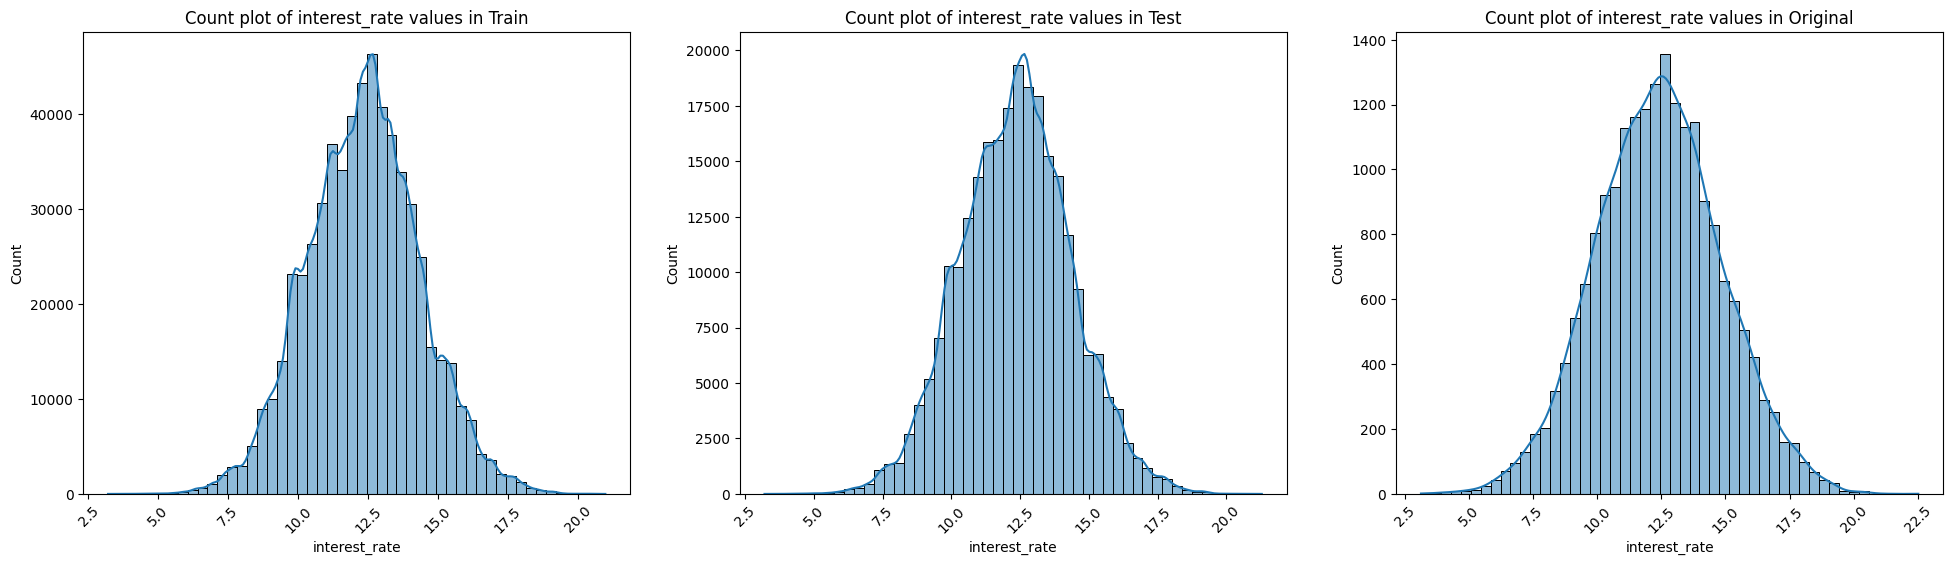

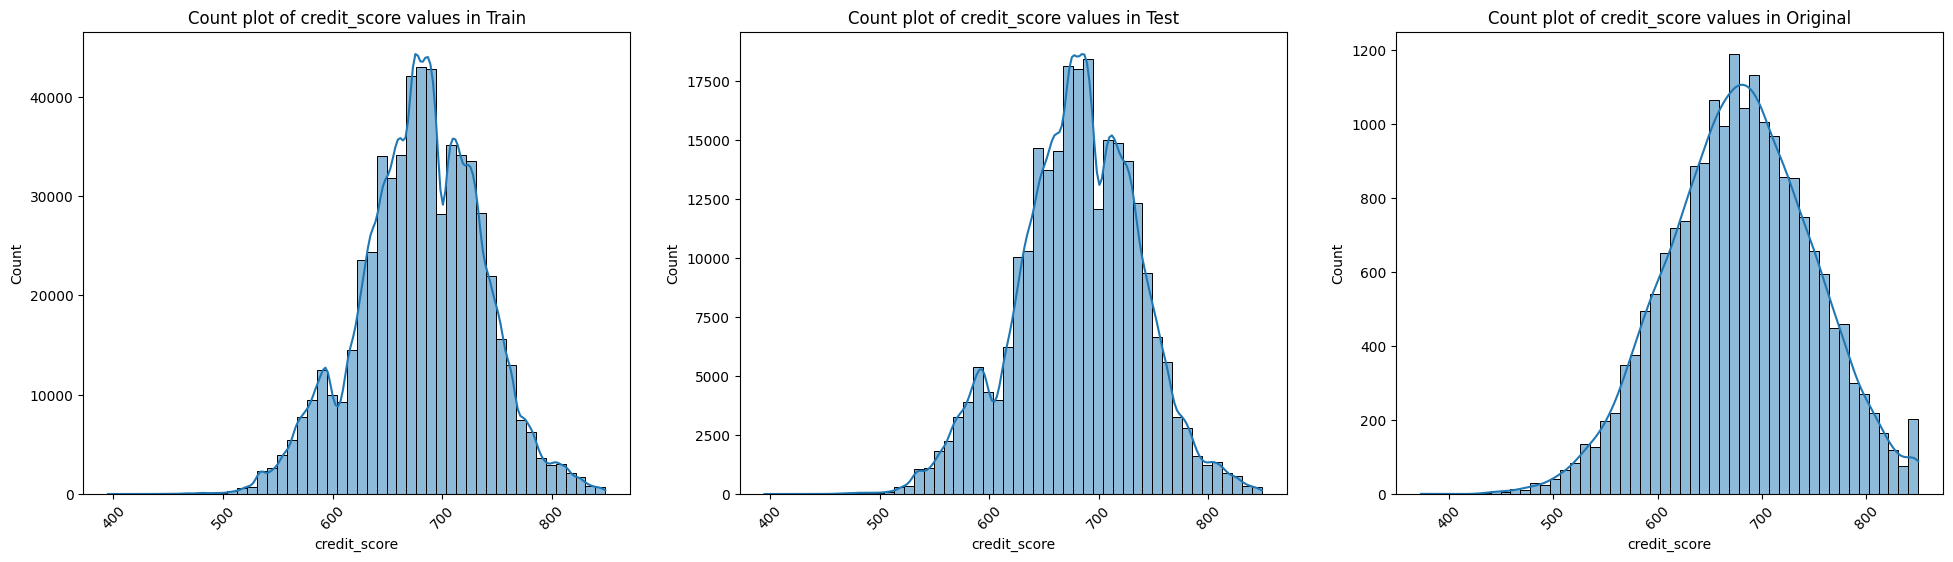

In [7]:
data_sets = [train_data, test_data, original_data]
data_set_names = ["Train", "Test", "Original"]
num_cols = numerical_features_train_test.copy()
num_cols.append('credit_score')

for feature in num_cols:
    plt.figure(figsize=(24, 6))
    for i in range(1, 4):
        plt.subplot(1, 3, i)
        sns.histplot(x=data_sets[i - 1][feature], bins=50,kde = True, label = feature)
        plt.title(f'Count plot of {feature} values in {data_set_names[i - 1]}')
        plt.xticks(rotation=45)
    plt.show()

# Analysis of produced plots:
- ## Annual income:
    We can see a right-skewed distribution of income, with a peak around 30,000 and a long tail reaching 350,000~400,000. The synthetic data distributions are jagged and bimodal, compared to the original data set. The right-skewedness along with a long tail suggests that logarithmic binning may be a good approach for preprocessing.
- ## Debt to income ratio:
    This case is similar to the 'Annual income' feature.
- ## Loan amount:
    The distributions for training and test sets are also right-skewed, but the tail is shorter than in previous features, so it starts to resemble a normal distribution. Interestingly, in the original data we can see a huge amount of very small loans, which was not accurately represented in the synthetic data set. These could be 'payday loans', often characterized by high interest rates.
- ## Interest rate:
    A perfect example of a normal distribution. Interest rate usually corresponds to loan risk.
- ## Credit score:
    While FICO scores have a range between 300 and 850, extremely low scores are rarely assigned, which corresponds to the data.

# Bivariate analysis
## Categorical features vs target

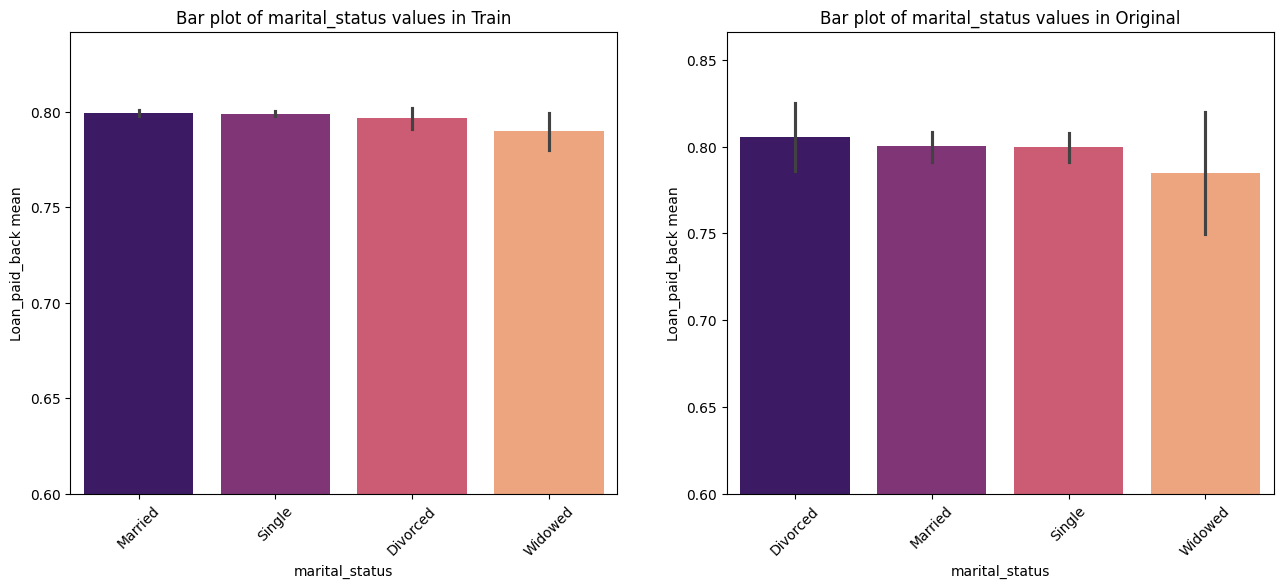

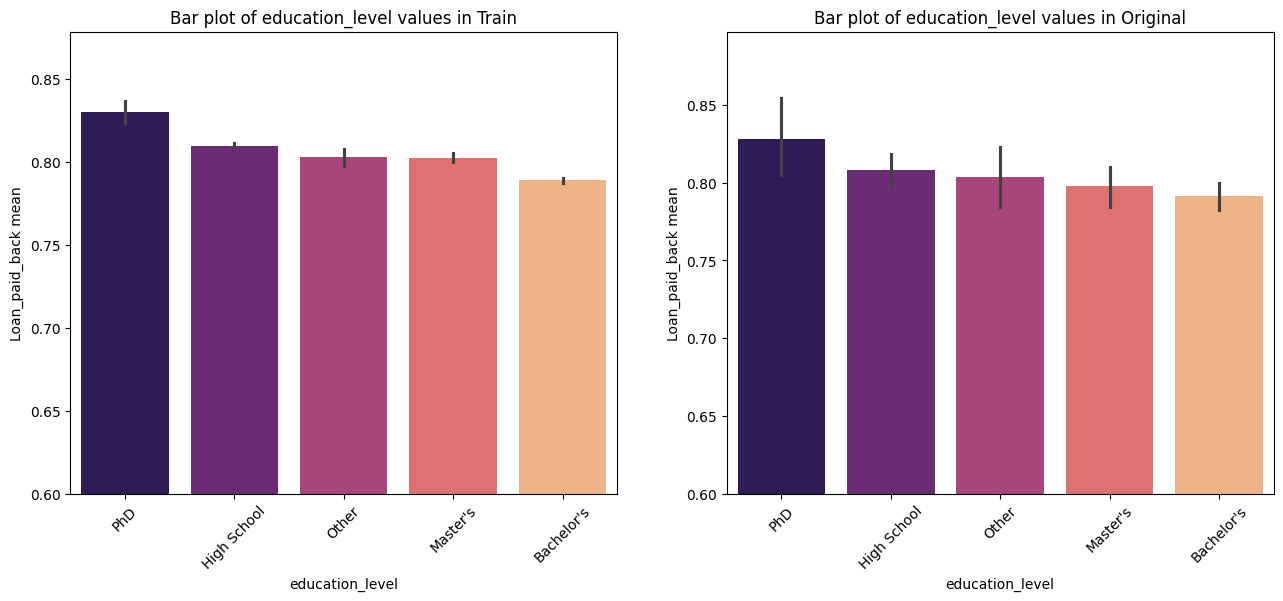

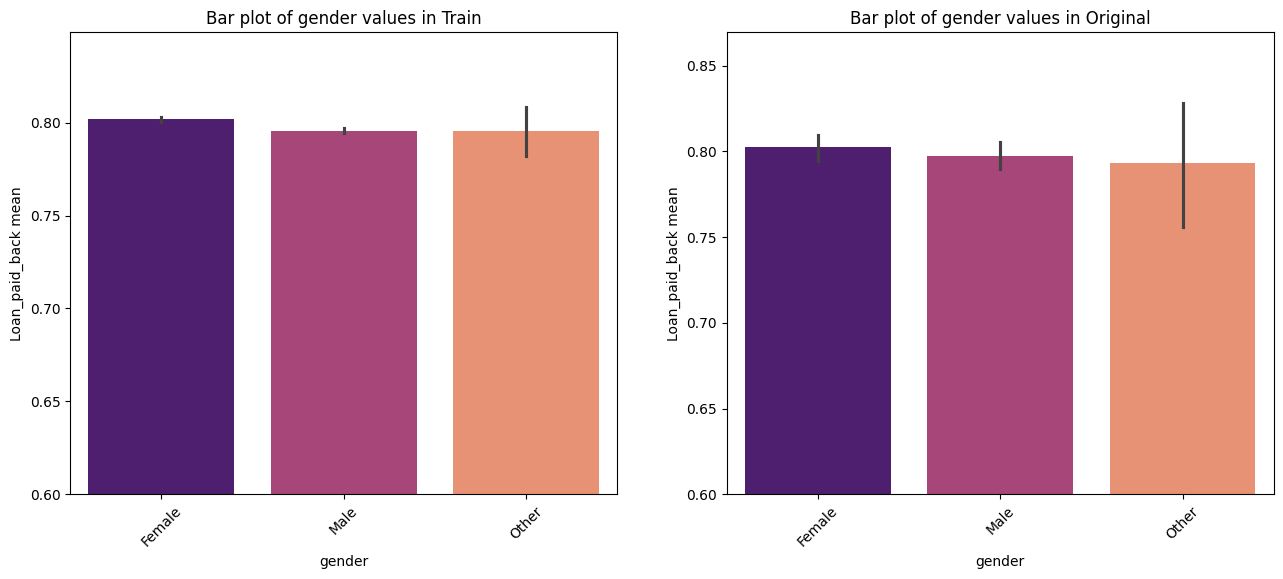

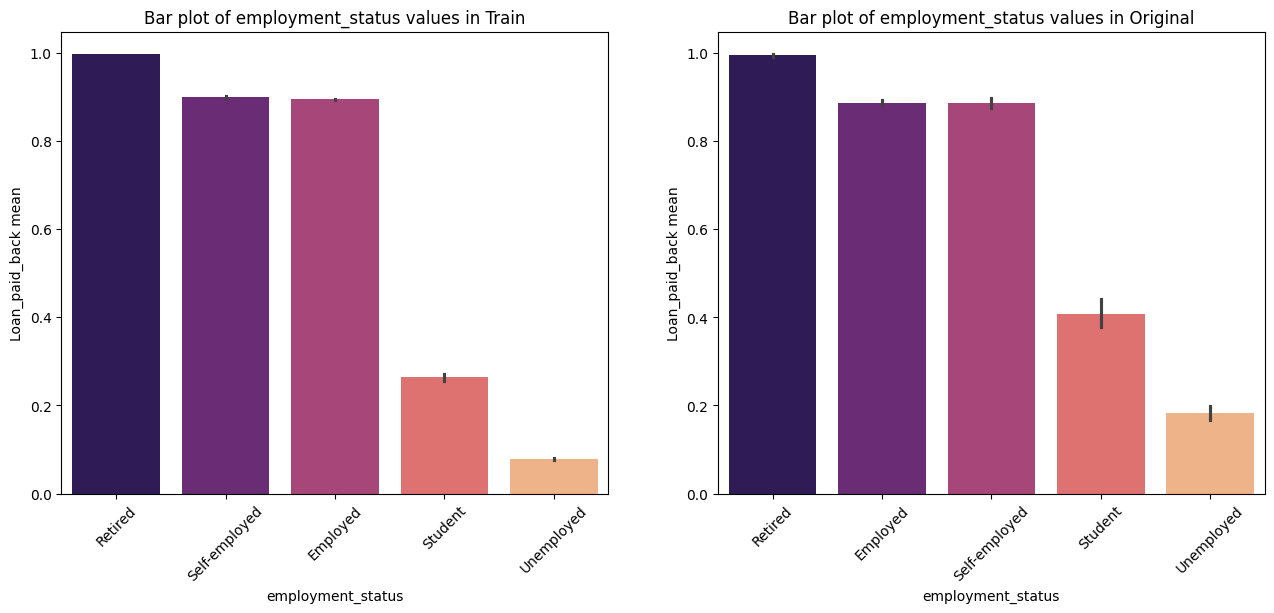

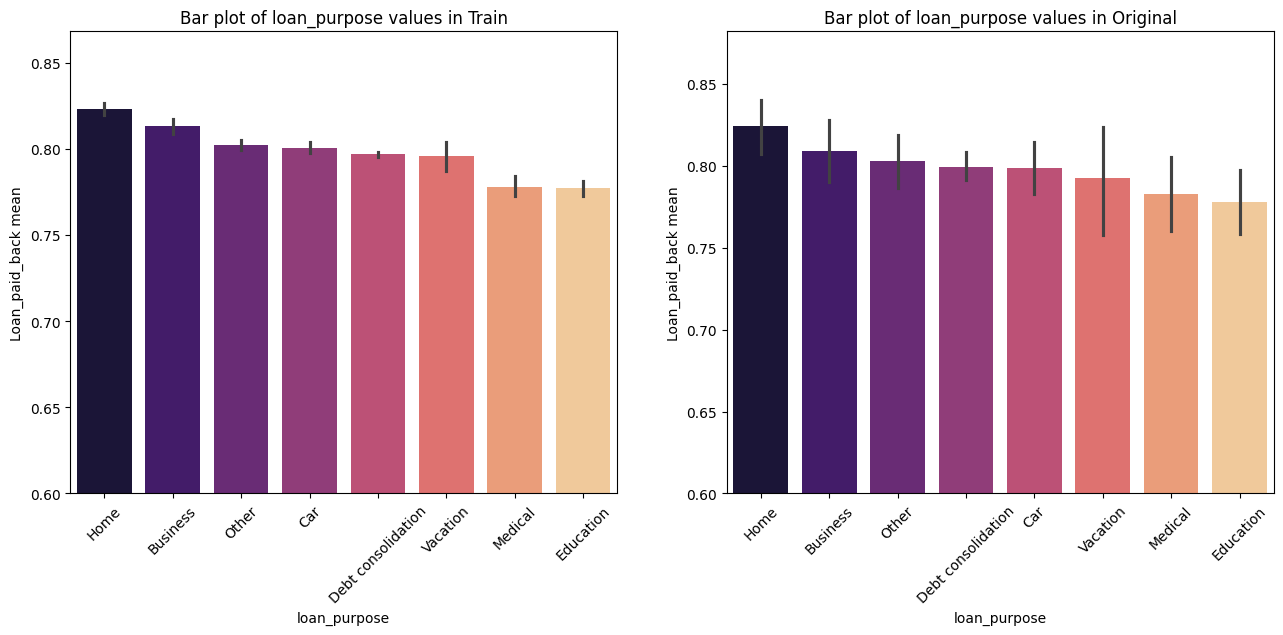

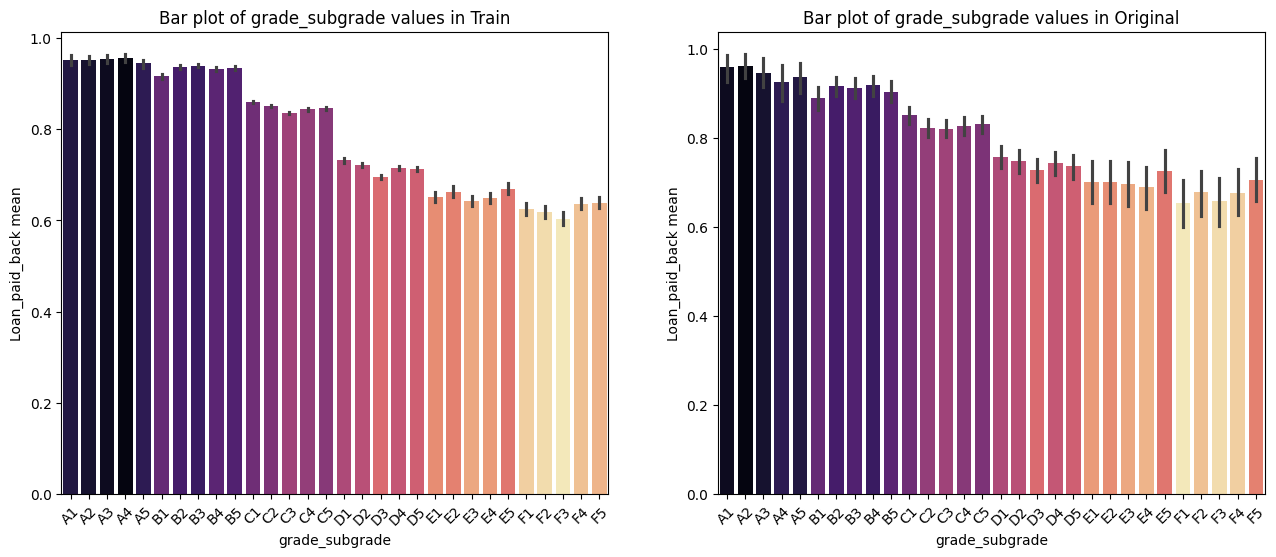

In [11]:
data_sets = [train_data, original_data]
excluded = ['employment_status', 'grade_subgrade']
data_set_names = ["Train", "Original"]
cat_cols = categorical_features_train_test.copy()
cat_cols.remove('credit_score')
for feature in cat_cols:
    plt.figure(figsize=(24, 6))
    for i in range(1,3):
        if feature == 'grade_subgrade':
            order = sorted(data_sets[i - 1][feature].unique())
            hue_order = data_sets[i - 1].groupby(feature)[target].mean().sort_values(ascending=False).index
        else:
            order = data_sets[i - 1].groupby(feature)[target].mean().sort_values(ascending=False).index
            hue_order = order
        plt.subplot(1, 2, i)
        sns.barplot(data=data_sets[i - 1][cat_cols + [target]], x=feature, y=target, order=order, palette='magma', hue=feature, hue_order=hue_order, legend=False)
        plt.title(f'Bar plot of {feature} values in {data_set_names[i - 1]}')
        plt.xticks(rotation=45)
        plt.ylabel("Loan_paid_back mean")
        if feature not in excluded:
            plt.ylim(bottom=0.6)
    plt.show()

# Analysis of produced plots
- ## Marital status
    As we can see from the plot, the means are nearly identical across all classes within this feature, and therefore we can come to a conclusion that it almost certainly doesn't produce any signal.
- ## Education level
    It can be seen that people with PhD's tend to pay back their loans a little bit more often than the rest, but we have to keep in mind that it's a minority class, so we cannot be sure if it's a real trend, or just a coincidence. The black lines on top of the bars represent uncertainty, and we have to look at the original data, because the model used for generation of the synthetic data set doesn't take that into account.
- ## Gender
    We can see that there isn't any significant variance to determine that this feature produces any signal.
- ## Employment status
    In this feature, there is high variance and a clear distinction between each class, except for 'Employed' and 'Self-employed'. It looks like the strongest categorical feature yet, in terms of producing signal for the model.
- ## Loan purpose
    In the original data set, we can see that there is not enough data to safely assume that the resulting distribution of means isn't a work of chance.
- ## Grade and subgrade
    Another good feature in terms of variance and statistical significance. There is a clear distinction between top and bottom grades.


# Numerical features vs target

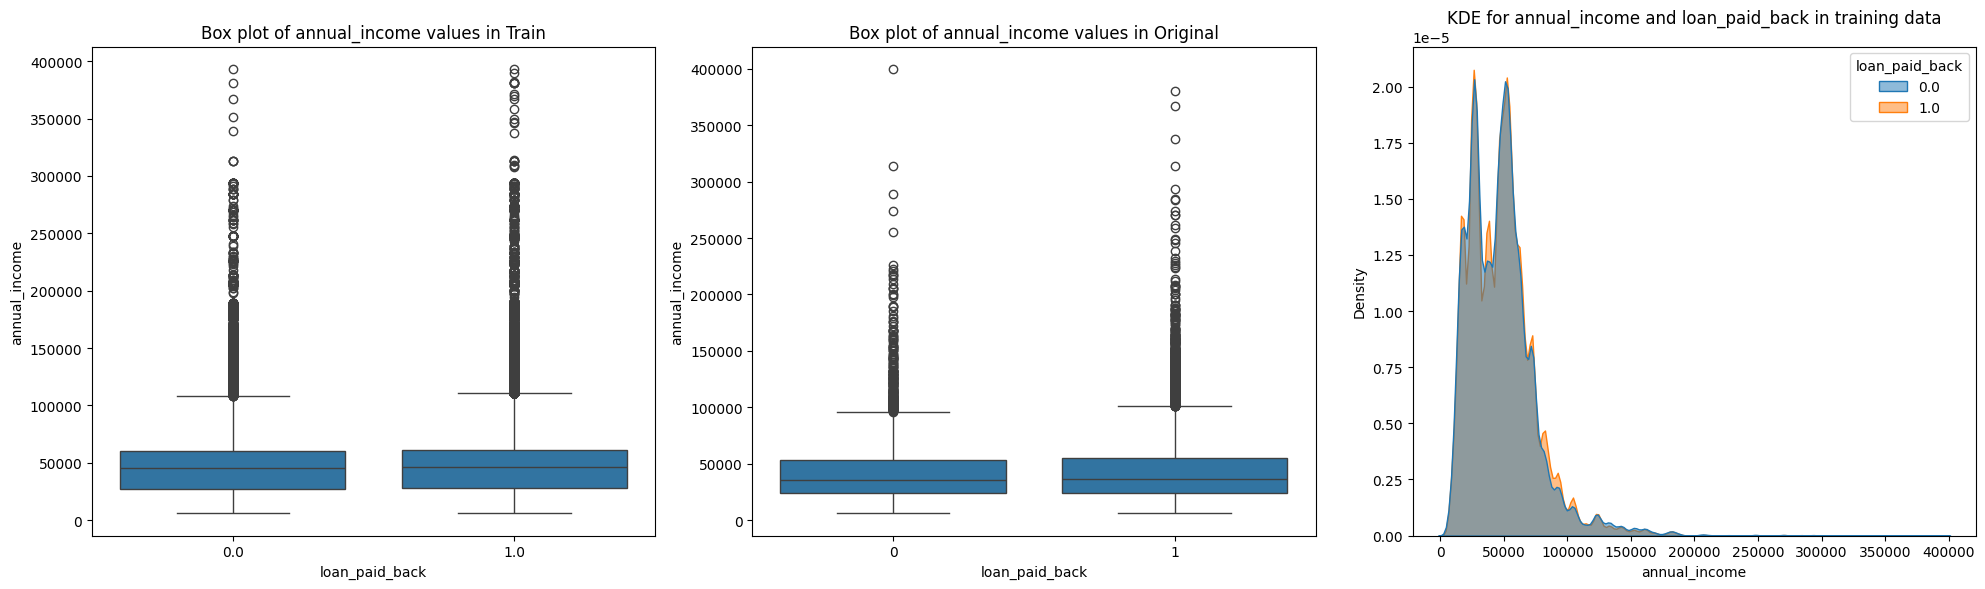

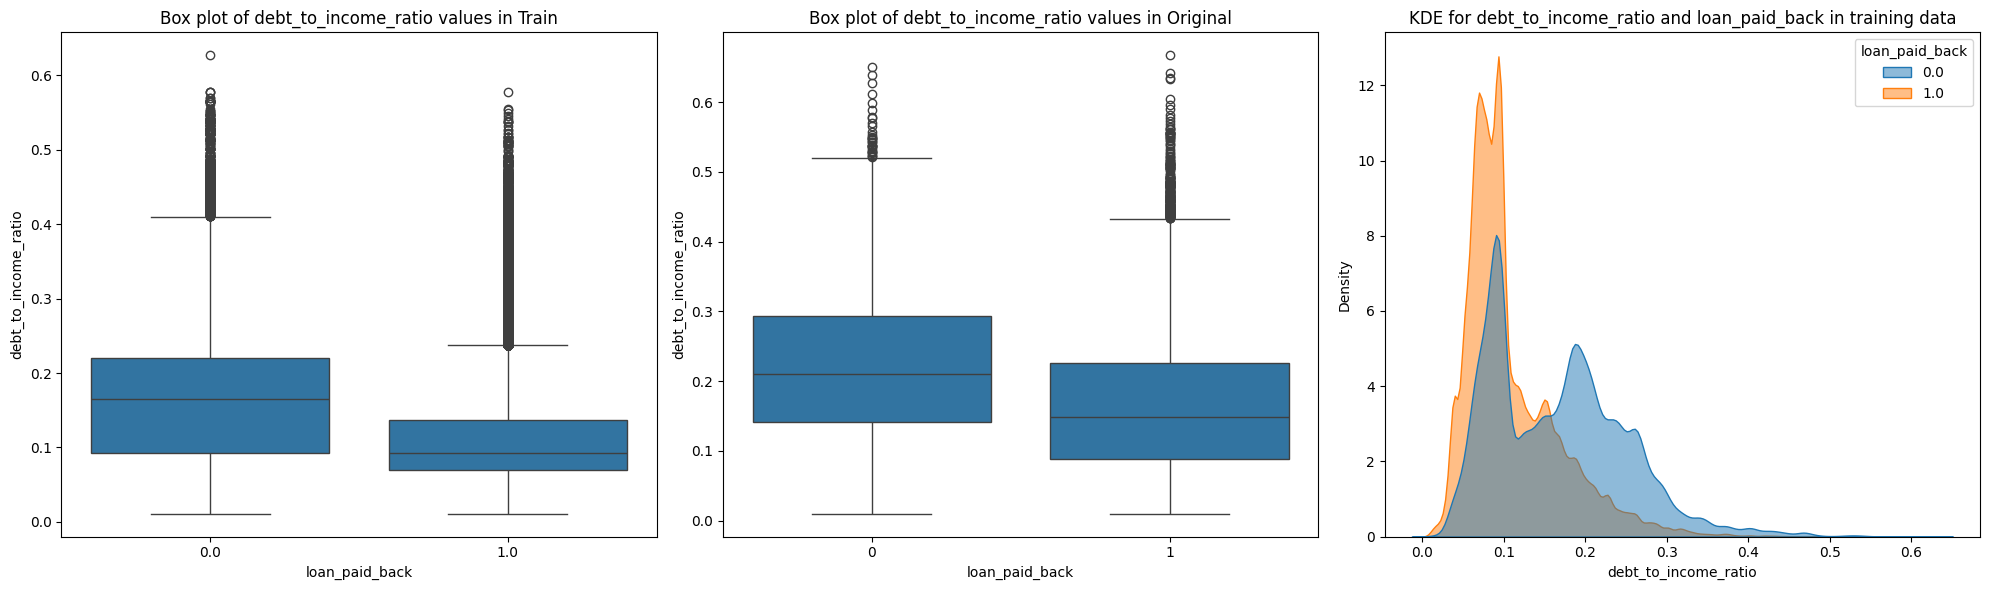

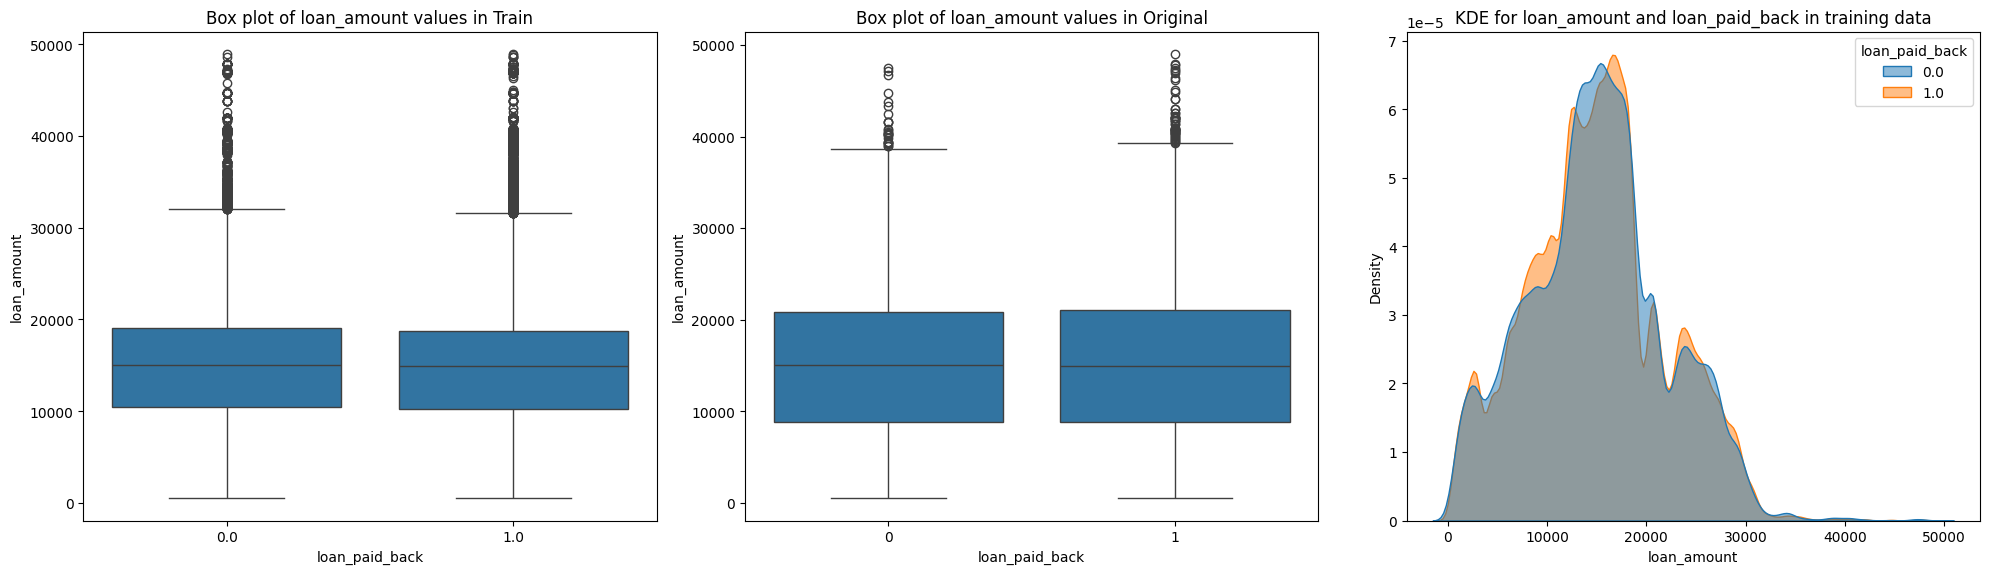

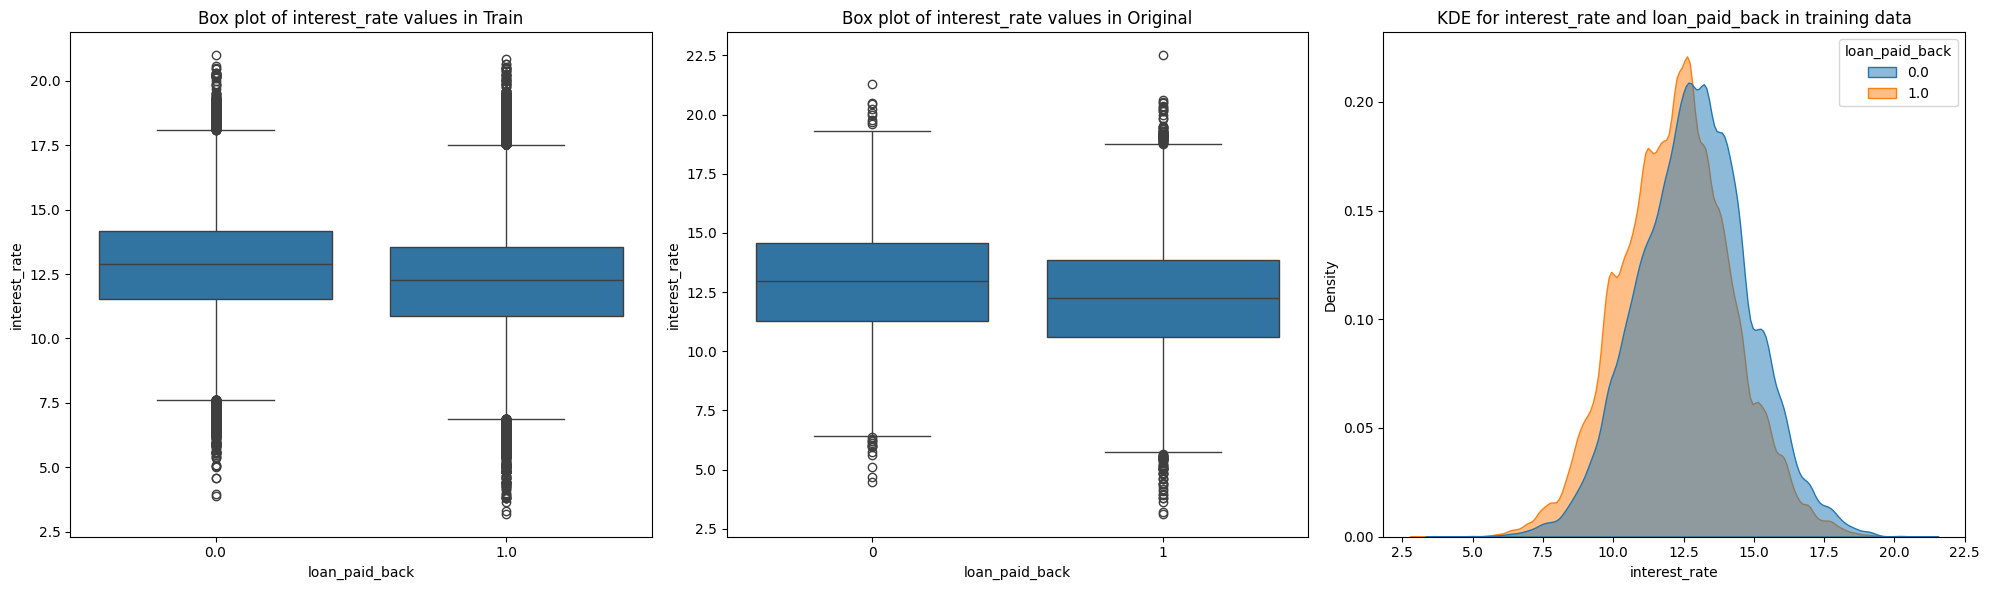

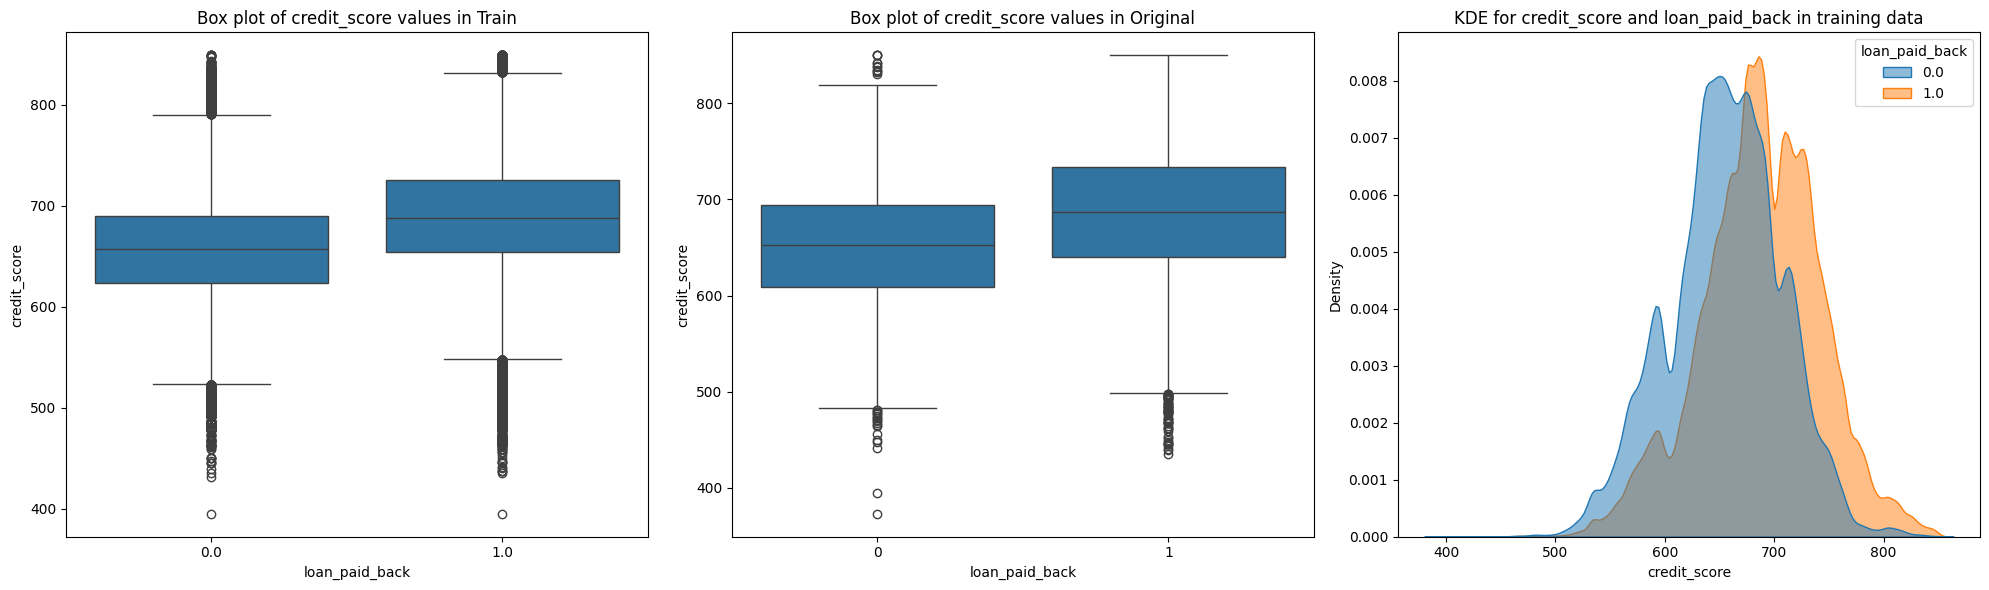

In [13]:
data_sets = [train_data, original_data]
data_set_names = ["Train", "Original"]
num_cols = numerical_features_train_test.copy()
num_cols.append('credit_score')

for feature in num_cols:
    plt.figure(figsize=(20, 6))
    for i in range(1, 4):
        plt.subplot(1, 3, i)
        if i == 3:
            sns.kdeplot(data=train_data, x=feature, hue=target, fill=True, common_norm=False, alpha=0.5)
            plt.title(f'KDE for {feature} and {target} in training data')
        else:
            sns.boxplot(data=data_sets[i - 1], x=target, y=feature)
            plt.title(f'Box plot of {feature} values in {data_set_names[i - 1]}')
    plt.tight_layout()
    plt.show()

# Analysis of produced plots
Each numerical feature has a significant number of outliers, which confirms that binning will be a good choice. For features 'Annual income' and 'Loan amount' there isn't enough distinction to say that these features produce much signal, since the boxes and density plots are nearly identical. The rest of the features most likely will produce meaningful signal.

# Comparison of numerical distributions between training and test data

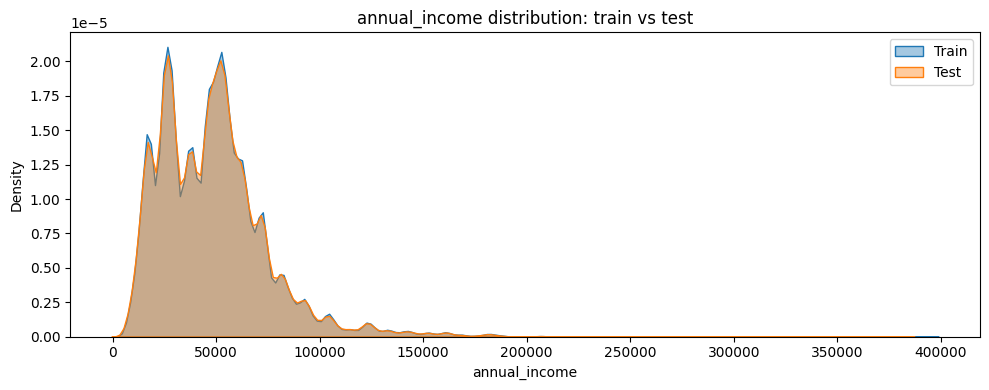

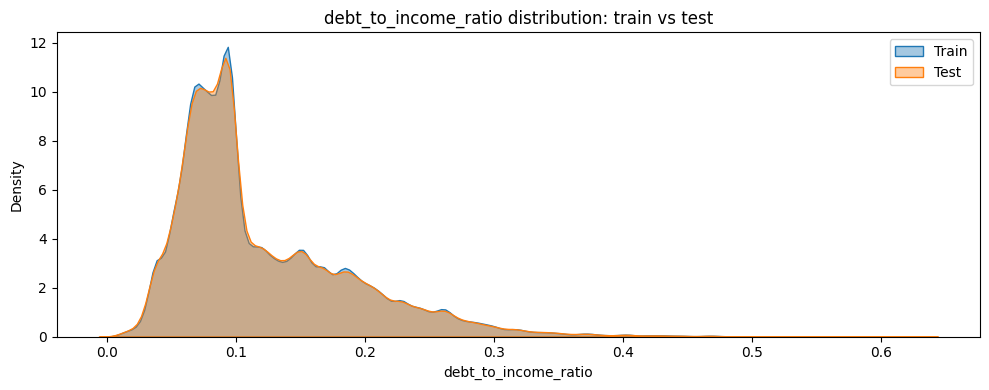

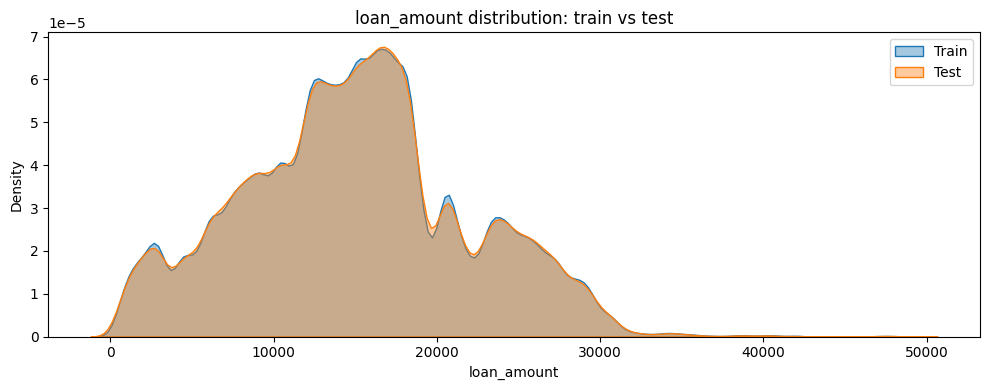

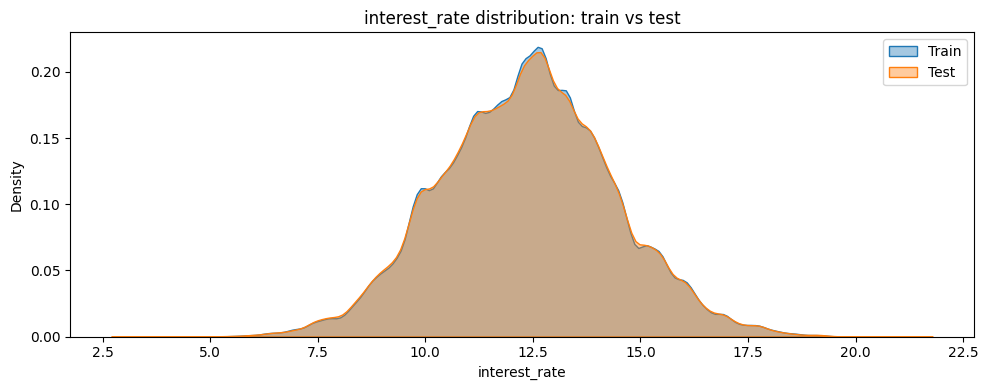

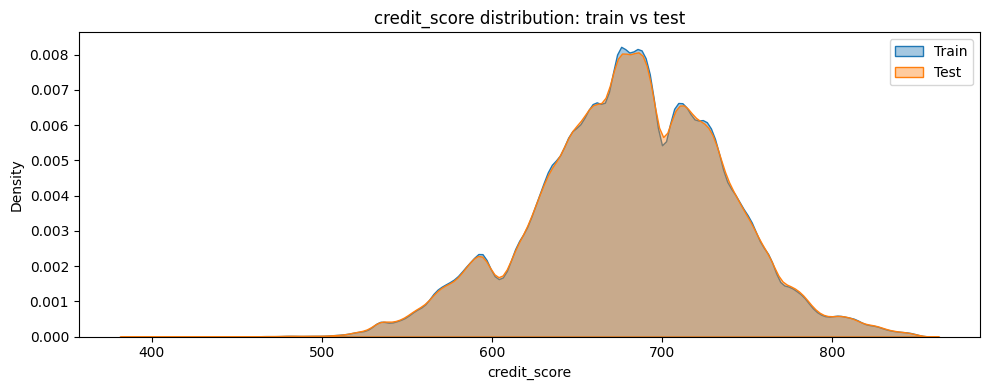

In [5]:
num_cols = numerical_features_train_test.copy()
num_cols.append('credit_score')

for column in num_cols:
    plt.figure(figsize=(10,4))
    sns.kdeplot(train_data[column], label="Train", fill=True, alpha=0.4)
    sns.kdeplot(test_data[column], label="Test", fill=True, alpha=0.4)
    plt.title(f"{column} distribution: train vs test")
    plt.legend()
    plt.tight_layout()
    plt.show()

As we can see, the distributions are almost identical, so we don't have to any standardization or normalization, nor use any scalers, etc.

# Multivariate analysis

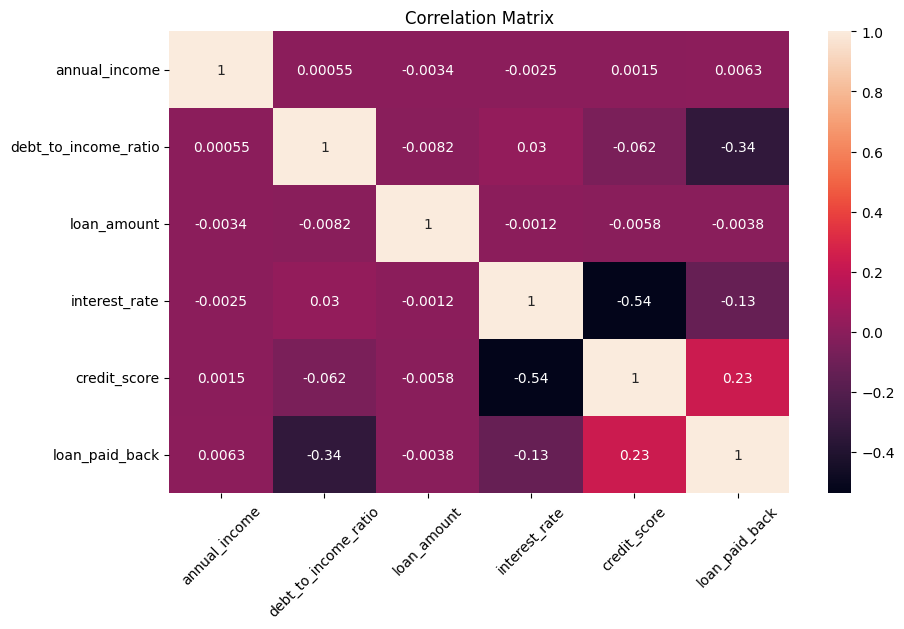

In [14]:
plt.figure(figsize = (10, 6))
corr_matrix = train_data[num_cols + [target]].corr()
sns.heatmap(corr_matrix, annot=True)

plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

# Correlation analysis
This correlation matrix confirms our previous assumptions, as debt to income ratio, interest rate, and credit score are possibly good predictors for the target value, since they are correlated with it. In addition, we can observe that the only correlated features are 'Credit score' and 'Interest rate', so they share some signal. All the other features are practically independent of each other.

# Quick overview of features unique to the original data set

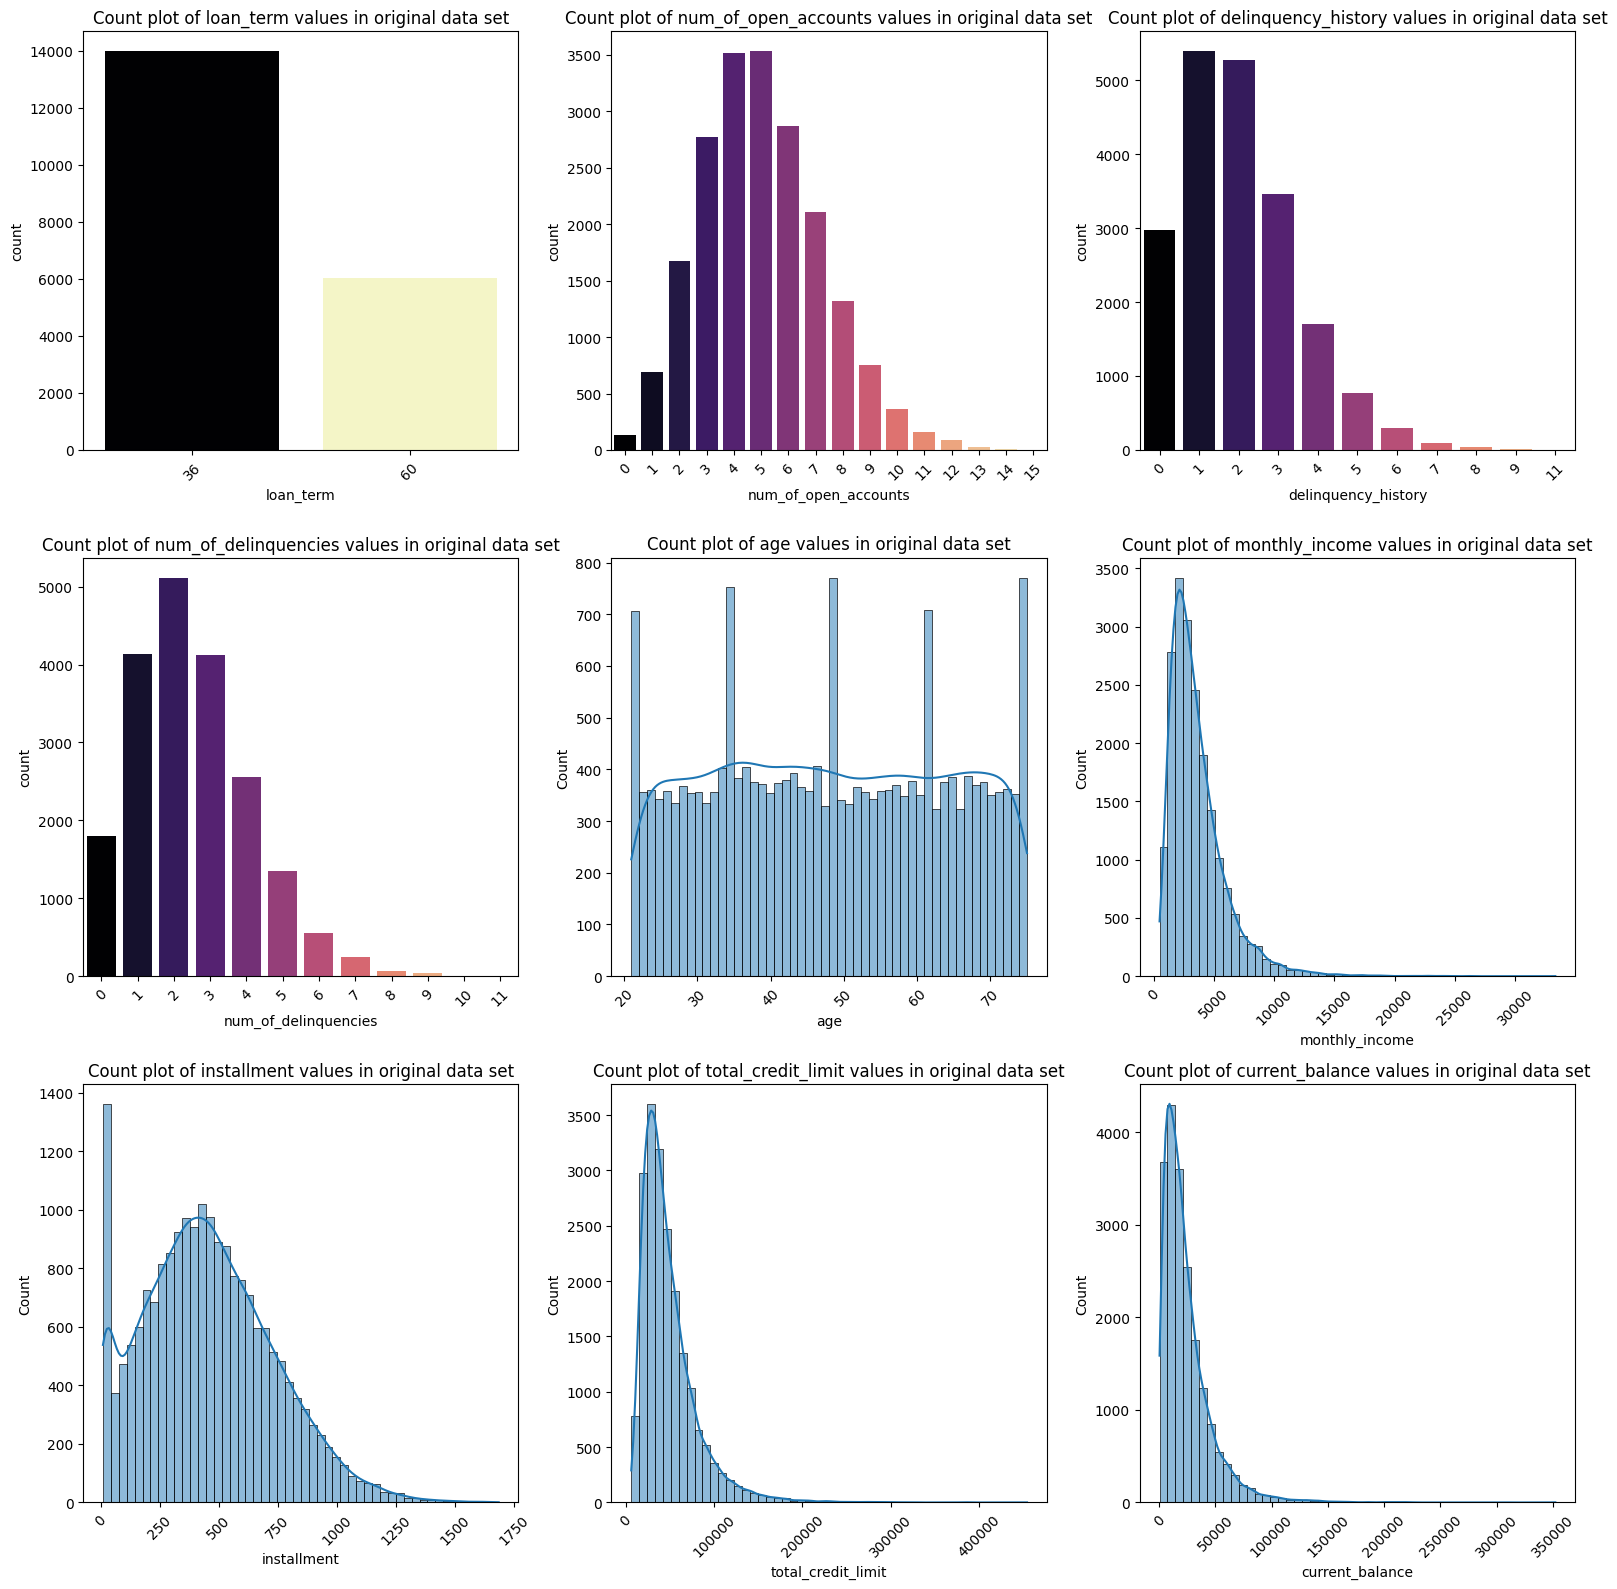

In [48]:
original_features = categorical_features_original_only + numerical_features_original_only
row = 1
idx = 1
plt.figure(figsize=(16, 16))
for feature in original_features:
    plt.subplot(3, 3, idx)

    if feature in categorical_features_original_only:
        sns.countplot(x = feature, data = original_data, hue = feature, palette='magma', legend = False)
        plt.title(f'Count plot of {feature} values in original data set')
        plt.xticks(rotation=45)
    else:
        sns.histplot(x=original_data[feature], bins=50 ,kde = True, label = feature)
        plt.title(f'Count plot of {feature} values in original data set')
        plt.xticks(rotation=45)
    idx += 1

plt.tight_layout()
plt.show()

# TODO omówienie

# Drift analysis

In [16]:
train_data['id_bucket'] = pd.qcut(train_data.index, q=10, labels=False)

drift_analysis = train_data.groupby('id_bucket')[['loan_amount', 'annual_income', 'interest_rate', 'loan_paid_back']].mean()

print(drift_analysis)

            loan_amount  annual_income  interest_rate  loan_paid_back
id_bucket                                                            
0          15025.112495   48216.556475      12.368354        0.796380
1          15037.936121   48209.472178      12.351021        0.797017
2          15010.284989   48114.165757      12.363412        0.799508
3          15060.391527   48371.673401      12.350306        0.798434
4          15047.209127   48174.317657      12.350887        0.800603
5          15022.188882   48044.515152      12.364109        0.799172
6          15004.881119   48132.210865      12.350956        0.799933
7          14999.641280   48343.651785      12.358161        0.798886
8          15034.788222   48239.498283      12.348345        0.799963
9          14960.543033   48275.965724      12.357901        0.798300


We can see that the mean of target value across following bins of ids are nearly identical, so we can assume that there isn't any implicit time drift present in the data. Therefore, there is no argument of using time series or chronological splits, and we opt to use stratified kfold approach.

# Grasping a vague approximation of feature importances from a basic model

In [23]:
cats = categorical_features_train_test.copy()
nums = numerical_features_train_test.copy()

encoder = OrdinalEncoder()
train_data[cats] = encoder.fit_transform(train_data[cats])

X = train_data.copy().drop(columns=['id_bucket', target])
y = train_data.copy()[target]

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns, name='Importance')
importances.sort_values(ascending=False)

employment_status       0.401082
debt_to_income_ratio    0.151220
loan_amount             0.083296
annual_income           0.082965
credit_score            0.082918
interest_rate           0.080259
grade_subgrade          0.046964
loan_purpose            0.026390
education_level         0.017620
marital_status          0.015589
gender                  0.011697
Name: Importance, dtype: float64

As expected, employments status appears to contain the highest amount of signal.

# TODO konkluzje